In [166]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gsw 

from tqdm.notebook import tqdm
from scipy.interpolate import interp1d
from profinder import get_example_data, find_profiles


In [179]:
ds=xr.open_dataset('L0-timeseries/wam_sbus_461_post_step_1.nc')  

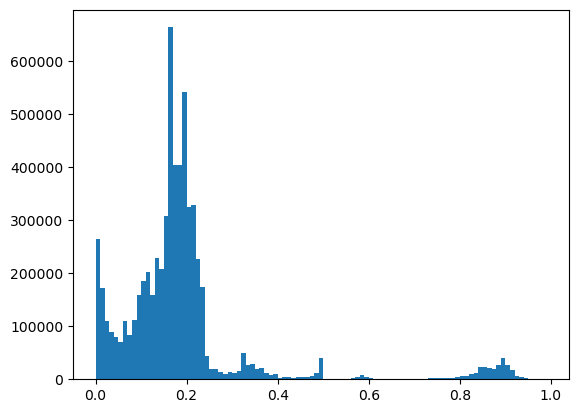

In [168]:
prespres = pd.Series(ds.pressure.values, dtype=float)

for _ in range(100):
    msk = prespres.diff().abs() > 0.5

    if not msk.any():
        break

    prespres[msk] = np.nan
    prespres = prespres.interpolate()

_ = plt.hist(np.abs(prespres.diff()), bins=np.arange(0,1,0.01))


In [169]:
ds['pressure_clean']=('time', prespres)
pressure = ds.pressure_clean.copy().bfill('time') #.isel(time=slice(3400000,3410000))

# segments = find_profiles(pressure)
peaks_kwargs = {"height": 15, "distance": 100, "width": 100, "prominence": 15}

segments = find_profiles(
  pressure, 
  apply_smoothing=True, 
  window_length=9, 
  min_pressure=0.0, 
  run_length=10, 
  peaks_kwargs=peaks_kwargs
  )

(120000.0, 135000.0)

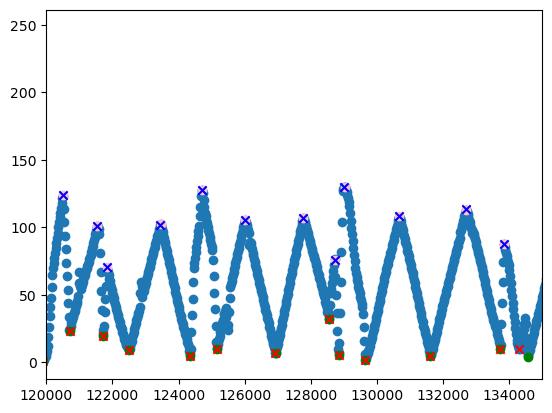

In [170]:
x = np.arange(0, pressure.size)
cut = slice(0, None, 20)  # reduce data for plotting

segments = np.asarray(segments)
start = segments[:, 0]
down_end = segments[:, 1]
up_start = segments[:, 2]
end = segments[:, 3]

plt.scatter(x[cut], pressure[cut])
plt.scatter(x[up_start], pressure[up_start], color="pink")
plt.scatter(x[start], pressure[start], color="green")
plt.scatter(x[down_end], pressure[down_end], color="blue" , marker = 'x')
plt.scatter(x[end], pressure[end], color="red", marker = 'x')

plt.xlim(120000,135000)
# fig.update_layout(yaxis_title="Pressure (dbar)", xaxis_title="Data index (-)", yaxis_autorange="reversed")
# HTML(fig.to_html(include_plotlyjs='cdn'))

In [171]:
import numpy as np
import xarray as xr

def assign_profile_cast_and_dive(pressure, top_idx, bottom_idx):
    n = pressure.sizes["time"]

    top_idx = np.sort(np.asarray(top_idx, dtype=int))
    bottom_idx = np.sort(np.asarray(bottom_idx, dtype=int))

    profile_index = np.full(n, np.nan)
    cast_direction = np.full(n, np.nan)   # -1 down, +1 up
    dive_number = np.full(n, np.nan)

    profile_id = 1
    dive_id = 1

    for i in range(len(top_idx) - 1):
        t0 = top_idx[i]
        t1 = top_idx[i + 1]

        bottoms_between = bottom_idx[(bottom_idx > t0) & (bottom_idx < t1)]

        if len(bottoms_between) == 0:
            print(f"No bottom between top indices {t0} and {t1}")
            continue

        b = bottoms_between[0]

        # same dive number for the whole top-to-top interval
        dive_number[t0:t1] = dive_id

        # downcast: top -> bottom
        profile_index[t0:b+1] = profile_id
        cast_direction[t0:b+1] = -1
        profile_id += 1

        # upcast: bottom -> next top
        profile_index[b+1:t1] = profile_id
        cast_direction[b+1:t1] = +1
        profile_id += 1

        dive_id += 1

    # handle last top
    if len(top_idx) > 0:
        t0 = top_idx[-1]
        bottoms_after = bottom_idx[bottom_idx > t0]

        if len(bottoms_after) == 0:
            print(f"No bottom found after last top index {t0}")
        else:
            b = bottoms_after[0]

            # last dive: from last top to end
            dive_number[t0:] = dive_id

            # downcast
            profile_index[t0:b+1] = profile_id
            cast_direction[t0:b+1] = -1
            profile_id += 1

            # upcast to end
            profile_index[b+1:] = profile_id
            cast_direction[b+1:] = +1

    return xr.Dataset(
        {
            "profile_number": (pressure.dims, profile_index),
            "cast_direction": (pressure.dims, cast_direction),
            "dive_number": (pressure.dims, dive_number),
            'pressure' : (pressure.dims, pressure.values)

        },
        coords=pressure.coords,
    )

In [172]:
ds_profiles = assign_profile_cast_and_dive(ds.pressure_clean,end, down_end)

No bottom between top indices 7449 and 7449
No bottom between top indices 71047 and 71047
No bottom between top indices 78318 and 78318
No bottom between top indices 315218 and 315218
No bottom between top indices 358789 and 358789
No bottom between top indices 452704 and 452704
No bottom between top indices 454272 and 454272
No bottom between top indices 457488 and 457488
No bottom between top indices 513078 and 513078
No bottom between top indices 552613 and 552613
No bottom between top indices 558796 and 558796
No bottom between top indices 798789 and 798789
No bottom between top indices 884719 and 884719
No bottom between top indices 940133 and 940133
No bottom between top indices 1190231 and 1190231
No bottom between top indices 1333291 and 1333291
No bottom between top indices 1405100 and 1405100
No bottom between top indices 1480022 and 1480022
No bottom found after last top index 6323365


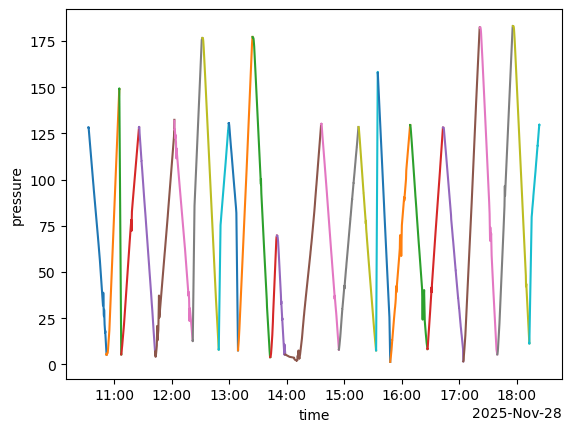

In [173]:
i=1000

for i in range(1000,1030,1):
    ds_profiles.groupby('profile_number')[i].pressure.plot()

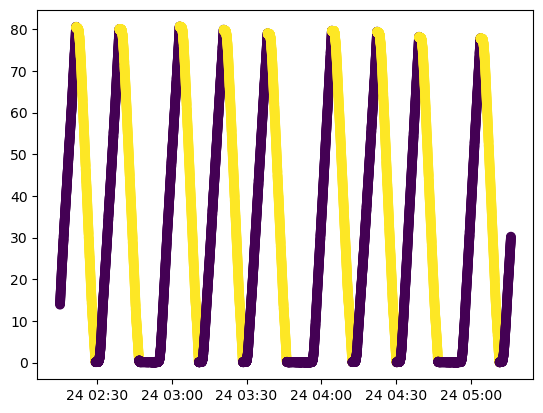

In [174]:
ds_plt= ds_profiles.isel(time=slice(6216260,6226260))

plt.scatter(ds_plt.time, ds_plt.pressure, c=ds_plt.cast_direction)

In [175]:
ds['profile_index']=('time', ds_profiles.profile_number.values)
ds['profile_direction']=('time', ds_profiles.cast_direction.values)
ds['dive_index']=('time', ds_profiles.dive_number.values)

In [176]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:                (time: 6326260)
Coordinates:
  * time                   (time) datetime64[ns] 51MB 2025-11-19T12:02:39 ......
    latitude               (time) float64 51MB ...
    longitude              (time) float64 51MB ...
    depth                  (time) float64 51MB ...
Data variables: (12/31)
    time_ctd               (time) datetime64[ns] 51MB ...
    m_pressure             (time) float64 51MB ...
    heading                (time) float64 51MB ...
    pitch                  (time) float64 51MB ...
    roll                   (time) float64 51MB ...
    conductivity           (time) float64 51MB ...
    ...                     ...
    pressure_corr2         (time) float64 51MB ...
    latitude_dmm           (time) float64 51MB ...
    longitude_dmm          (time) float64 51MB ...
    pressure_raw           (time) float64 51MB ...
    m_pressure_raw         (time) float64 51MB ...
    pressure_clean         (time) float64 51MB nan nan nan ... 0.3954 0.3954
Attributes: (12/61)
    Conventions:               CF-1.8
    Metadata_Conventions:      CF-1.8, Unidata Dataset Discovery v1.0
    acknowledgement:           Funding from Schmitt Sciences, OBVI, West Afri...
    cdm_data_type:             Trajectory
    comment:                   Southern Benguela Upwelling System glider depl...
    contributor_name:          Sarah Nicholson, Isabelle Giddy, Estel Font, N...
    ...                        ...
    summary:                   First leg of the Southern Benguela Upwelling S...
    time_coverage_end:         2026-03-25T13:32:56.000000000
    time_coverage_start:       2006-06-13T06:49:39.000000000
    title:                     socco-461461-20060613T0649
    transmission_system:       IRRIDIUM
    wmo_id:                    999999

In [177]:
ds.to_netcdf('L0-timeseries/wam_sbus_461_post_step_2.nc')